Load the data from Evgenia and the confidence from BDA preprocessing and combine everything in dictionaries

In [1]:
import numpy as np
import json
from collections import OrderedDict, defaultdict
from confdl import reformat_json, Vocabulary, Dataset

def merge_records(j_data: dict, confidences: list):
    
    data = dict()
    
    for k, v in j_data.items():
        for datum in v:
            record = data.get(datum['id'], None)
            if record is None:
                record = dict()
                data[datum['id']] = record
            record[f"J/{datum['rater']}"] = datum['label']

    
        for datum in confidences:
            record = data.get(datum['item'], None)
            if record is None:
                record = dict()
                data[datum['item']] = record
            record[f"Q/{datum['system']}"] = datum['posterior_confidence']

    return data


In [2]:
import json

# experiment = 'ambig_qa_multiple_qas_llama-3b-instruct_100_0'
experiment = 'trivia_qa_llama-8b-instruct_incl_human_judges'
input_file = f"data/{experiment}.json"
keep = {
    'human_judge1', 
    'human_judge2', 
    'llm_as_judge_gpt-5.4-mini', 
    'llm_as_judge_llama-8b-instruct',
    'exact_match', 
    # 'rouge_l/0.1', 
    'bert_score/0.3', 
    # 'bert_score/0.8', 
    'bert_score/0.9', 
    'log_likelihood_seq', 
    'log_likelihood_token', 
    'entropy', 
    'semantic_entropy', 
    'semantic_confidence', 
    'verbalised_confidence', 
    'p_true'
}
jrows, _ = reformat_json(
    input_file,
    keep=keep
)

with open(f"inferences/{experiment}.confidences.json", 'r') as fp:
    confidences = json.load(fp)

data = merge_records(jrows, confidences)

In [3]:
# data['3103857971526342341']

Create tables for pandas (there may be easier ways, but my pandas is limited)

In [4]:
import pandas as pd

order = sorted(data.keys())

q_header = ['item', 'quantifier', 'confidence']
j_header = ['item', 'judge', 'label', 'correct', 'category']
q_table = []
j_table = []

oracle_j = 'J/human_judge1'

for uid in order:
    for k, v in sorted(data[uid].items(), key=lambda pair: pair[0]):
        if k.startswith('J/'):
            if data[uid][oracle_j] == v:
                cat = 'TP' if v else 'TN'
            else:
                cat = 'FP' if v else 'FN'
            j_table.append([uid, k, v, data[uid][oracle_j] == v, cat])
        else:
            q_table.append([uid, k, v])

df_q = pd.DataFrame(q_table, columns=q_header)
df_j = pd.DataFrame(j_table, columns=j_header)
df_j

,item,judge,label,correct,category
0,bb_1342,J/bert_score/0.3,True,True,TP
1,bb_1342,J/bert_score/0.9,False,False,FN
2,bb_1342,J/exact_match,False,False,FN
3,bb_1342,J/human_judge1,True,True,TP
4,bb_1342,J/human_judge2,True,True,TP
...,...,...,...,...,...
695,wh_3695,J/exact_match,False,True,TN
696,wh_3695,J/human_judge1,False,True,TN
697,wh_3695,J/human_judge2,True,False,FP
698,wh_3695,J/llm_as_judge_gpt-5.4-mini,True,False,FP


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=0.9)

# Study a specific combination of Judge and Quantifier

<Axes: xlabel='confidence', ylabel='category'>

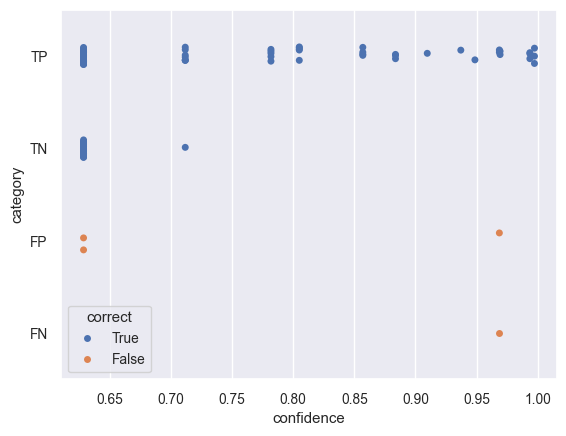

In [10]:
df_ = pd.merge(
    df_q[df_q['quantifier']=='Q/entropy'],
    # df_j[df_j['judge']=='J/llm_as_judge_llama-8b-instruct'],
    df_j[df_j['judge']=='J/human_judge2'],
    on='item', how='outer'
)
sns.stripplot(
    data=df_,
    x='confidence',
    y='category',
    hue='correct',
    hue_order=[True, False],
    order=['TP', 'TN', 'FP', 'FN']
)

# Study all Judge-Quantifier pairs

In [7]:
df_qj = pd.merge(
    df_q,
    df_j,
    on='item', how='outer'
)
df_qj

,item,quantifier,confidence,judge,label,correct,category
0,bb_1342,Q/entropy,0.628795,J/bert_score/0.3,True,True,TP
1,bb_1342,Q/entropy,0.628795,J/bert_score/0.9,False,False,FN
2,bb_1342,Q/entropy,0.628795,J/exact_match,False,False,FN
3,bb_1342,Q/entropy,0.628795,J/human_judge1,True,True,TP
4,bb_1342,Q/entropy,0.628795,J/human_judge2,True,True,TP
...,...,...,...,...,...,...,...
4895,wh_3695,Q/verbalised_confidence,0.868129,J/exact_match,False,True,TN
4896,wh_3695,Q/verbalised_confidence,0.868129,J/human_judge1,False,True,TN
4897,wh_3695,Q/verbalised_confidence,0.868129,J/human_judge2,True,False,FP
4898,wh_3695,Q/verbalised_confidence,0.868129,J/llm_as_judge_gpt-5.4-mini,True,False,FP


It takes a few seconds, be patient

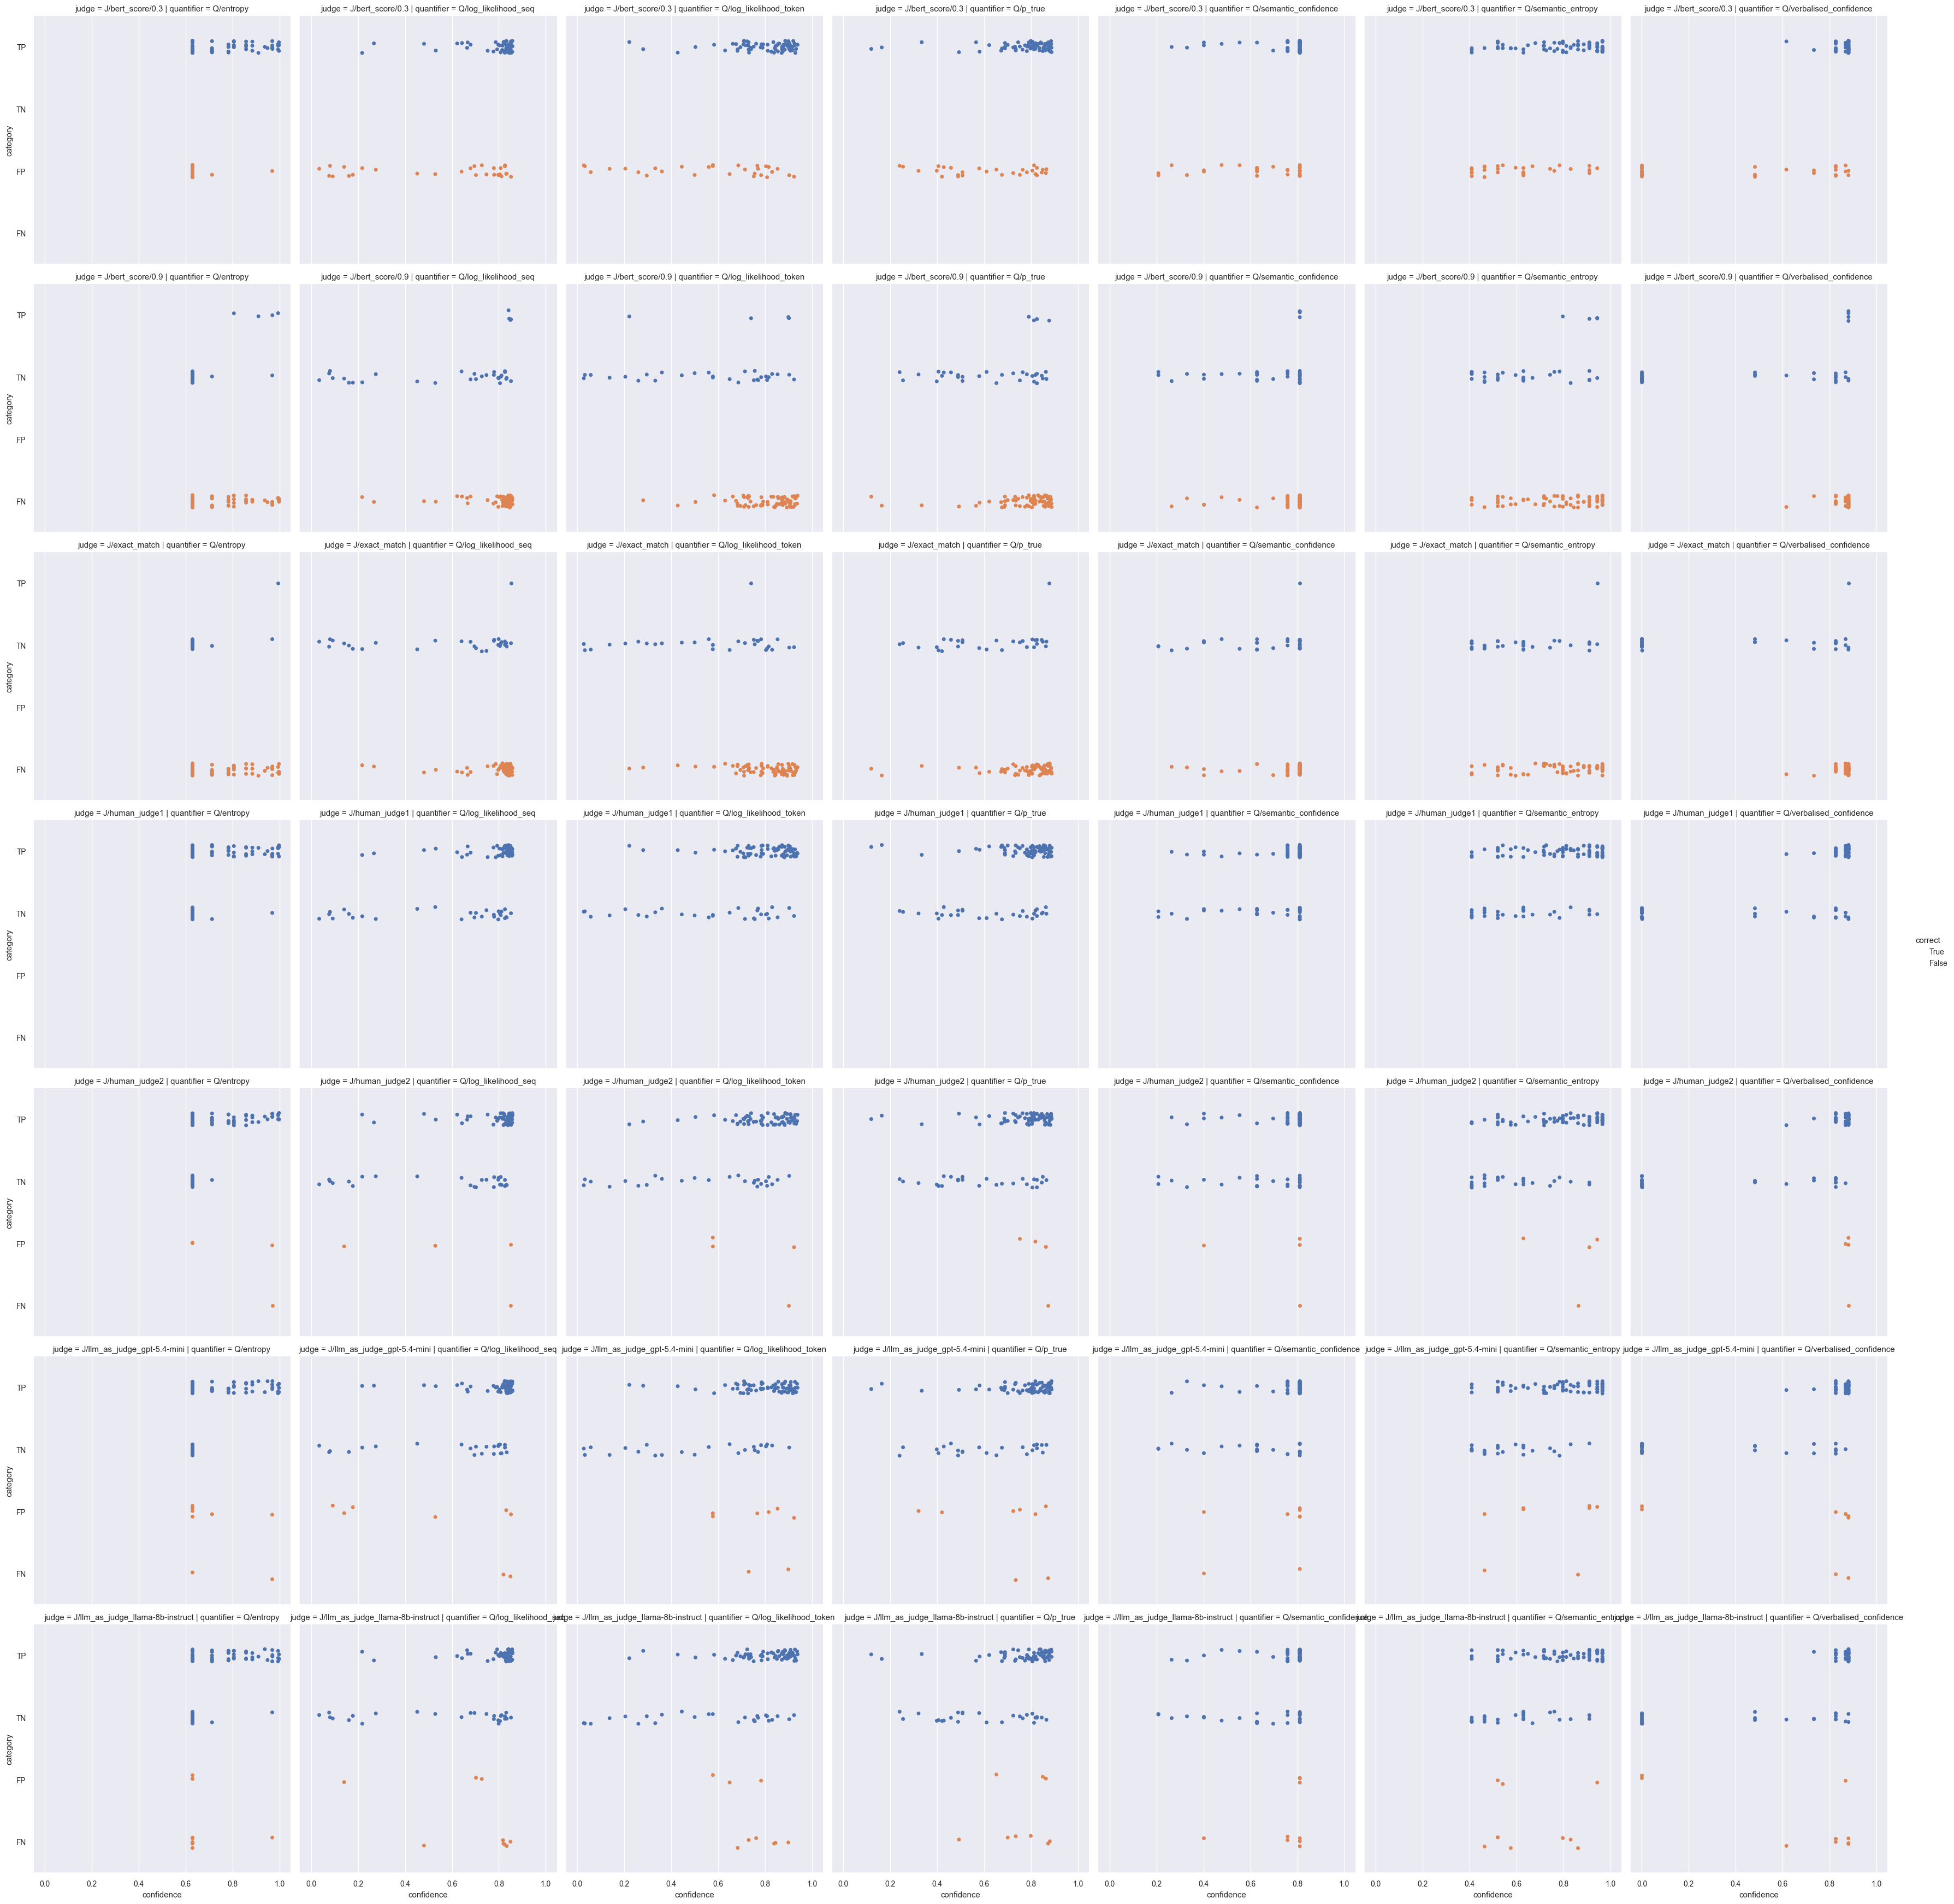

In [8]:
sns.catplot(
    data=df_qj,
    x='confidence',
    y='category',
    hue="correct",
    col='quantifier',
    row='judge',
    kind='strip',
    hue_order=[True, False],
    order=['TP', 'TN', 'FP', 'FN']
)